# Q9c: 时变因子权重
> Bayesian Ridge 36月滚动 → 每月输出连续权重 → 对比固定等权 / 开关式 / 连续权重

**输入**: Q9b 扩展因子池 (9因子), 行业中性化
**方法**: Bayesian Ridge (自动正则化, 无需调参, 可解释的系数)
**对比**: 固定等权 / 开关式(|t|>1.5) / Bayesian Ridge 连续权重
**验证**: 36月滚动训练 → 下月打分 → Top Q, 29个月出样本

In [1]:
#=== Cell 1: Imports ===
import numpy as np, pandas as pd
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt, seaborn as sns
import warnings, time
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')
CACHE = Path('research_cache')

from matplotlib.font_manager import FontProperties
import matplotlib as mpl
_cjk_fp = None
_avail = {f.name for f in mpl.font_manager.fontManager.ttflist}
for _fn in ['Microsoft YaHei', 'SimHei', 'Noto Sans SC']:
    if _fn in _avail:
        _cjk_fp = FontProperties(fname=mpl.font_manager.findfont(_fn))
        break
if _cjk_fp is None:
    _cjk_fp = FontProperties()

from sklearn.linear_model import BayesianRidge, LinearRegression
from sklearn.preprocessing import StandardScaler

def _port_sort(df, factor, n_groups=5):
    if factor not in df.columns or 'fwd_ret_1m' not in df.columns:
        return None
    months = sorted(df['month'].unique())
    q_rets = {q: [] for q in range(1, n_groups+1)}
    spreads = []
    for m in months:
        dm = df[df['month']==m][[factor, 'fwd_ret_1m']].dropna().copy()
        if len(dm) < n_groups*5:
            continue
        try:
            dm['q'] = pd.qcut(dm[factor], n_groups, labels=False, duplicates='drop') + 1
        except Exception:
            continue
        if dm['q'].nunique() < n_groups:
            continue
        for q in range(1, n_groups+1):
            q_rets[q].append(dm.loc[dm['q']==q, 'fwd_ret_1m'].mean())
        spreads.append(dm.loc[dm['q']==n_groups, 'fwd_ret_1m'].mean() - dm.loc[dm['q']==1, 'fwd_ret_1m'].mean())
    result = {}
    for q in range(1, n_groups+1):
        vals = [v for v in q_rets[q] if not np.isnan(v)]
        result[f'Q{q}'] = np.mean(vals) if vals else np.nan
    spread_arr = np.array([s for s in spreads if not np.isnan(s)])
    if len(spread_arr) > 5:
        result['spread'] = np.mean(spread_arr)
        result['t_spread'] = np.mean(spread_arr) / (np.std(spread_arr, ddof=1) / np.sqrt(len(spread_arr)))
    else:
        result['spread'] = np.nan
        result['t_spread'] = 0
    result['n_months'] = len(spread_arr)
    return result

print('Cell 1 OK')

Cell 1 OK


---
## Cell 2: 加载 Q9b 面板 + 因子方向
> 复用 Q9a 的数据加载和方向映射

In [2]:
#=== Cell 2: 加载数据 ===
df = pd.read_csv(CACHE / 'q9b_panel.csv', dtype={'code': str})
df['month'] = pd.to_datetime(df['month'])

FEATURES = ['reversal_n', 'momentum_2_12_n', 'volatility_n',
            'turnover_ratio_n', 'turnover_change_n', 'high_low_spread_n',
            'amihud_n', 'extreme_ret_n', 'ret_skew_n']
TARGET = 'fwd_ret_1m'

df = df.dropna(subset=FEATURES + [TARGET])

FACTOR_SIGN = {
    'reversal_n': +1, 'momentum_2_12_n': -1, 'volatility_n': -1,
    'turnover_ratio_n': -1, 'turnover_change_n': -1, 'high_low_spread_n': -1,
    'amihud_n': +1, 'extreme_ret_n': +1, 'ret_skew_n': -1,
}

ROLL_MONTHS = sorted(df['month'].unique())
LOOKBACK = 36
print(f'面板: {df.shape[0]} 条, {df["month"].nunique()} 月, {df["code"].nunique()} 只')
print(f'出样本: {ROLL_MONTHS[LOOKBACK].date()} ~ {ROLL_MONTHS[-1].date()} ({len(ROLL_MONTHS)-LOOKBACK} 月)')

面板: 22647 条, 65 月, 401 只
出样本: 2024-01-31 ~ 2026-05-31 (29 月)


---
## Cell 3: 市场状态特征构造
> 训练集内算：过去 N 月 reversal spread 累计、市场波动率、大小盘风格差
> 这些特征帮助时变权重模型判断「当前市场适不适合反转策略」

In [3]:
#=== Cell 3: 市场状态特征 ===
def _compute_market_state(train_df):
    """给定训练集 (36月面板), 提取市场状态特征"""
    months = sorted(train_df['month'].unique())
    if len(months) < 6:
        return {}

    # 等权市场收益
    market_rets = train_df.groupby('month')[TARGET].mean()

    state = {}
    # 过去 6 月市场累计收益 (动量行情 vs 反转行情)
    state['market_cum_6m'] = (1 + market_rets.tail(6)).prod() - 1
    # 过去 3 月市场波动率
    state['market_vol_3m'] = market_rets.tail(3).std()
    # 过去 6 月 reversal spread 均值 (反转因子近期表现)
    rev_monthly = []
    for m in months[-6:]:
        dm = train_df[train_df['month'] == m].copy()
        if len(dm) >= 100:
            try:
                dm['q'] = pd.qcut(dm['reversal_n'], 5, labels=False, duplicates='drop') + 1
                rev_spread = dm[dm['q'] == 5][TARGET].mean() - dm[dm['q'] == 1][TARGET].mean()
                rev_monthly.append(rev_spread)
            except Exception:
                pass
    state['reversal_spread_6m'] = np.mean(rev_monthly) if rev_monthly else 0

    # 过去 6 月大小盘风格 (micro vs small: 最小组 20% vs 最大组 20% 的 return 差)
    size_spreads = []
    for m in months[-6:]:
        dm = train_df[train_df['month'] == m].copy()
        if 'log_mv' not in dm.columns and len(dm) >= 100:
            continue
        # 用 amihud_n 作为 size 代理 (流动性 = 市值代理)
        if 'amihud_n' in dm.columns and len(dm) >= 100:
            try:
                dm['q'] = pd.qcut(dm['amihud_n'], 5, labels=False, duplicates='drop') + 1
                size_spread = dm[dm['q'] == 1][TARGET].mean() - dm[dm['q'] == 5][TARGET].mean()
                size_spreads.append(size_spread)
            except Exception:
                pass
    state['size_spread_6m'] = np.mean(size_spreads) if size_spreads else 0

    return state

print('Market state function defined')

Market state function defined


---
## Cell 4: Bayesian Ridge 时变权重 — 主回测循环
> 每月: 训练 Bayesian Ridge → 提取系数 → 用系数 × 因子方向 = 权重 → 打分

In [4]:
#=== Cell 4: Bayesian Ridge 时变权重 ===
def rolling_bayesian_ridge():
    results = []
    weights_history = []
    state_history = []

    for i, m in enumerate(ROLL_MONTHS):
        if i < LOOKBACK:
            continue
        train = df[(df['month'] >= ROLL_MONTHS[i-LOOKBACK]) & (df['month'] < m)]
        test = df[df['month'] == m].copy()

        if len(train) < 200 or len(test) < 50:
            continue

        X_train = train[FEATURES].values
        y_train = train[TARGET].values
        X_test = test[FEATURES].values

        # Scale
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()
        X_train_s = scaler_X.fit_transform(X_train)
        y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
        X_test_s = scaler_X.transform(X_test)

        # Bayesian Ridge
        br = BayesianRidge(max_iter=300, tol=1e-3, alpha_1=1e-6, alpha_2=1e-6,
                           lambda_1=1e-6, lambda_2=1e-6)
        br.fit(X_train_s, y_train_s)

        # 预测
        pred_s = br.predict(X_test_s)
        pred = scaler_y.inverse_transform(pred_s.reshape(-1, 1)).ravel()

        test['pred'] = pred
        test['q'] = pd.qcut(test['pred'], 5, labels=False, duplicates='drop') + 1

        if test['q'].nunique() < 3:
            continue

        top_ret = test[test['q'] == 5][TARGET].mean()
        bot_ret = test[test['q'] == 1][TARGET].mean()
        all_ret = test[TARGET].mean()

        # OOS R^2
        ss_res = ((test[TARGET].values - pred) ** 2).sum()
        ss_tot = ((test[TARGET].values - test[TARGET].mean()) ** 2).sum()
        oos_r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0

        results.append({
            'month': m, 'top_ret': top_ret, 'bot_ret': bot_ret,
            'spread': top_ret - bot_ret, 'market': all_ret, 'oos_r2': oos_r2
        })

        # Record weights (BR coefficients * factor direction)
        weights = {}
        for j, f in enumerate(FEATURES):
            weights[f] = br.coef_[j] * FACTOR_SIGN[f]
        weights['month'] = m
        weights_history.append(weights)

        # Record market state
        state = _compute_market_state(train)
        state['month'] = m
        state_history.append(state)

    rec = pd.DataFrame(results)
    if not rec.empty:
        rec['cum_top'] = (1 + rec['top_ret']).cumprod()
        rec['cum_market'] = (1 + rec['market']).cumprod()
    return rec, pd.DataFrame(weights_history), pd.DataFrame(state_history)

print('Training Bayesian Ridge rolling...')
t0 = time.time()
rec_br, wgt_br, st_br = rolling_bayesian_ridge()
if not rec_br.empty:
    top_ann = rec_br['top_ret'].mean() * 12 * 100
    spread_ann = rec_br['spread'].mean() * 12 * 100
    market_ann = rec_br['market'].mean() * 12 * 100
    spread_t = rec_br['spread'].mean() / (rec_br['spread'].std() / np.sqrt(len(rec_br)))
    avg_r2 = np.mean(rec_br['oos_r2'])
    print(f'Bayesian Ridge: Top年化={top_ann:.1f}% Market={market_ann:.1f}% Spread={spread_ann:.1f}% t={spread_t:.2f} R^2={avg_r2:.4f} | {time.time()-t0:.0f}s')

Training Bayesian Ridge rolling...


Bayesian Ridge: Top年化=12.4% Market=9.2% Spread=19.5% t=3.94 R^2=-0.7854 | 1s


---
## Cell 5: 两个 baseline — 固定等权 + 开关式自适应
> 用同样的因子池，三种权重方案对比

In [5]:
#=== Cell 5: Baselines ===
def rolling_fixed_weight():
    """固定等权: 所有因子 1/N, 方向由 FACTOR_SIGN 确定"""
    results = []
    for i, m in enumerate(ROLL_MONTHS):
        if i < LOOKBACK:
            continue
        test = df[df['month'] == m].copy()
        if len(test) < 50:
            continue

        test['score'] = 0
        for f in FEATURES:
            mu, sigma = test[f].mean(), test[f].std()
            if sigma > 0:
                test['score'] += FACTOR_SIGN[f] * (test[f] - mu) / sigma
        test['score'] /= len(FEATURES)

        test['q'] = pd.qcut(test['score'], 5, labels=False, duplicates='drop') + 1
        if test['q'].nunique() < 3:
            continue
        results.append({
            'month': m,
            'top_ret': test[test['q'] == 5][TARGET].mean(),
            'bot_ret': test[test['q'] == 1][TARGET].mean(),
            'spread': test[test['q'] == 5][TARGET].mean() - test[test['q'] == 1][TARGET].mean(),
            'market': test[TARGET].mean()
        })
    rec = pd.DataFrame(results)
    if not rec.empty:
        rec['cum_top'] = (1 + rec['top_ret']).cumprod()
        rec['cum_market'] = (1 + rec['market']).cumprod()
    return rec


def rolling_switch():
    """开关式: 每月用训练集选 |t|>1.5 的因子, 等权"""
    results = []
    for i, m in enumerate(ROLL_MONTHS):
        if i < LOOKBACK:
            continue
        train = df[(df['month'] >= ROLL_MONTHS[i-LOOKBACK]) & (df['month'] < m)]
        test = df[df['month'] == m].copy()
        if len(test) < 50:
            continue

        # Select factors with |t|>1.5 on training set
        valid = []
        for f in FEATURES:
            sr = _port_sort(train, f)
            if abs(sr['t_spread']) > 1.5 and sr['n_months'] > 12:
                valid.append(f)
        if not valid:
            valid = FEATURES[:3]

        test['score'] = 0
        for f in valid:
            mu, sigma = test[f].mean(), test[f].std()
            if sigma > 0:
                test['score'] += FACTOR_SIGN[f] * (test[f] - mu) / sigma
        test['score'] /= len(valid)

        test['q'] = pd.qcut(test['score'], 5, labels=False, duplicates='drop') + 1
        if test['q'].nunique() < 3:
            continue
        results.append({
            'month': m,
            'top_ret': test[test['q'] == 5][TARGET].mean(),
            'bot_ret': test[test['q'] == 1][TARGET].mean(),
            'spread': test[test['q'] == 5][TARGET].mean() - test[test['q'] == 1][TARGET].mean(),
            'market': test[TARGET].mean()
        })
    rec = pd.DataFrame(results)
    if not rec.empty:
        rec['cum_top'] = (1 + rec['top_ret']).cumprod()
        rec['cum_market'] = (1 + rec['market']).cumprod()
    return rec


rec_fixed = rolling_fixed_weight()
rec_switch = rolling_switch()

for label, rec in [('固定等权', rec_fixed), ('开关式', rec_switch), ('Bayesian Ridge', rec_br)]:
    if not rec.empty:
        top = rec['top_ret'].mean() * 12 * 100
        spread = rec['spread'].mean() * 12 * 100
        market = rec['market'].mean() * 12 * 100
        st = rec['spread'].mean() / (rec['spread'].std() / np.sqrt(len(rec)))
        print(f'{label:16s}: Top年化={top:5.1f}% Market={market:5.1f}% Spread={spread:5.1f}% t={st:+.2f}')

固定等权            : Top年化= 14.9% Market=  9.2% Spread= 25.4% t=+3.45
开关式             : Top年化= 14.6% Market=  9.2% Spread= 24.7% t=+3.42
Bayesian Ridge  : Top年化= 12.4% Market=  9.2% Spread= 19.5% t=+3.94


---
## Cell 6: 三种方案对比图
> 累计收益曲线 + 权重热力图

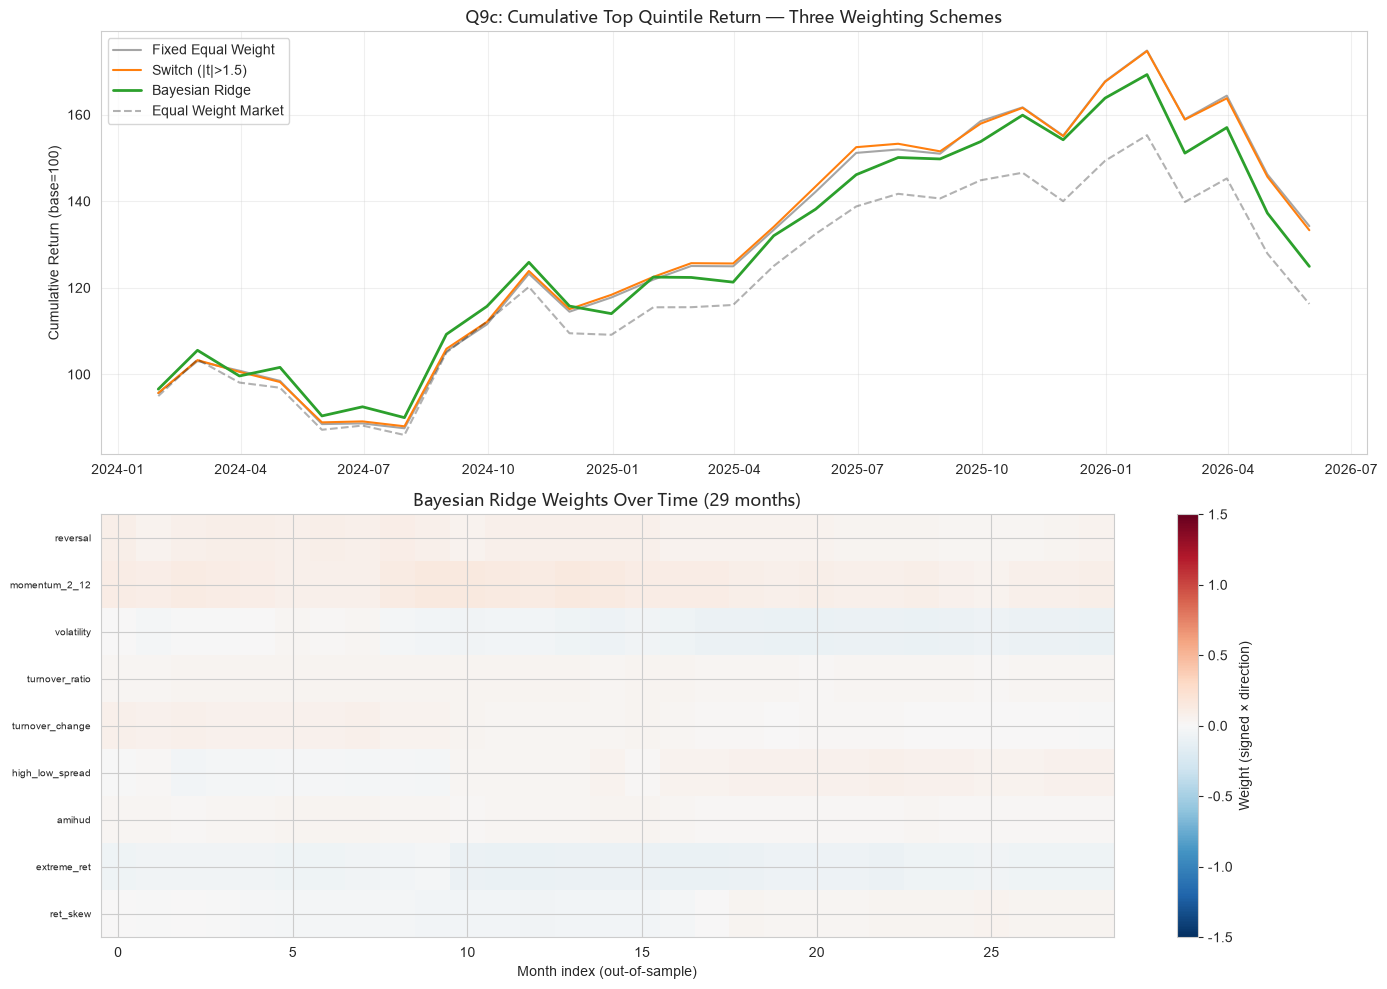

In [6]:
#=== Cell 6: 对比图 ===
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# --- Top panel: cumulative return ---
ax1.plot(rec_fixed['month'], rec_fixed['cum_top']*100, color='tab:grey', label='Fixed Equal Weight', alpha=0.7)
ax1.plot(rec_switch['month'], rec_switch['cum_top']*100, color='tab:orange', label='Switch (|t|>1.5)')
ax1.plot(rec_br['month'], rec_br['cum_top']*100, color='tab:green', label='Bayesian Ridge', linewidth=2)
ax1.plot(rec_fixed['month'], rec_fixed['cum_market']*100, color='black', alpha=0.3, linestyle='--', label='Equal Weight Market')
ax1.set_title('Q9c: Cumulative Top Quintile Return — Three Weighting Schemes', fontproperties=_cjk_fp, fontsize=12)
ax1.set_ylabel('Cumulative Return (base=100)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Bottom panel: weight heatmap ---
if not wgt_br.empty:
    wm = wgt_br.set_index('month')[FEATURES]
    # Clip for visualization
    wm_clip = wm.clip(wm.quantile(0.05).min(), wm.quantile(0.95).max())
    im = ax2.imshow(wm_clip.T.values, aspect='auto', cmap='RdBu_r', interpolation='nearest', vmin=-1.5, vmax=1.5)
    ax2.set_yticks(range(len(FEATURES)))
    short_names = [f.replace('_n','') for f in FEATURES]
    ax2.set_yticklabels(short_names, fontsize=7)
    ax2.set_xlabel('Month index (out-of-sample)')
    ax2.set_title(f'Bayesian Ridge Weights Over Time ({len(wm)} months)', fontproperties=_cjk_fp, fontsize=12)
    plt.colorbar(im, ax=ax2, label='Weight (signed × direction)')

plt.tight_layout()
plt.savefig(CACHE / 'q9c_weight_compare.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 7: 权重统计 — 哪些因子在不同市场状态下被放大/缩小
> 月度权重的均值/std，以及权重与市场状态的相关性

In [7]:
#=== Cell 7: 权重统计 ===
if not wgt_br.empty:
    wm = wgt_br.set_index('month')[FEATURES]

    print('=== 因子权重统计 (Bayesian Ridge) ===')
    print(f'{"Factor":30s} | {"Mean":>8s} | {"Std":>8s} | {"Pos%":>8s} | {"Info":>10s}')
    print('-' * 75)
    for f in FEATURES:
        mean_w = wm[f].mean()
        std_w = wm[f].std()
        pos_pct = (wm[f] > 0).mean() * 100
        # 有效 = 权重方向与预设一致 (权重为正 = 因子在朝预设方向工作)
        aligned = 'consistent' if mean_w > 0 else 'REVERSED!'
        print(f'{f:30s} | {mean_w:+7.4f} | {std_w:7.4f} | {pos_pct:7.1f}% | {aligned}')

    # 权重与市场状态的相关性
    if not st_br.empty:
        sm = st_br.set_index('month')
        aligned = wm.index.intersection(sm.index)
        wm_a = wm.loc[aligned]
        sm_a = sm.loc[aligned]

        print(f'\n=== 因子权重 × 市场状态相关性 ===')
        state_cols = [c for c in sm.columns if c != 'month']
        for sf in state_cols:
            if sf not in sm_a.columns or sm_a[sf].std() == 0:
                continue
            for ff in FEATURES[:4]:  # 只看 Q8 核心因子的状态响应
                corr_val = wm_a[ff].corr(sm_a[sf])
                if abs(corr_val) > 0.3:
                    direction = '增加权重' if corr_val > 0 else '降低权重'
                    print(f'  {sf} → {ff}: r={corr_val:+.2f} ({direction})')
else:
    print('No weight data')

=== 因子权重统计 (Bayesian Ridge) ===
Factor                         |     Mean |      Std |     Pos% |       Info
---------------------------------------------------------------------------
reversal_n                     | +0.0617 |  0.0205 |   100.0% | consistent
momentum_2_12_n                | +0.1006 |  0.0267 |   100.0% | consistent
volatility_n                   | -0.0534 |  0.0423 |    17.2% | REVERSED!
turnover_ratio_n               | +0.0335 |  0.0081 |   100.0% | consistent
turnover_change_n              | +0.0343 |  0.0264 |    96.6% | consistent
high_low_spread_n              | +0.0276 |  0.0385 |    69.0% | consistent
amihud_n                       | +0.0254 |  0.0071 |   100.0% | consistent
extreme_ret_n                  | -0.0712 |  0.0205 |     0.0% | REVERSED!
ret_skew_n                     | -0.0009 |  0.0352 |    48.3% | REVERSED!

=== 因子权重 × 市场状态相关性 ===
  market_cum_6m → reversal_n: r=-0.32 (降低权重)
  market_cum_6m → volatility_n: r=-0.62 (降低权重)
  market_vol_3m → reversal_

---
## Q9c 结论

### 三种方案对比 (29 个月出样本, 2024-01 ~ 2026-05)

| 权重方案 | Top 年化 | Spread 年化 | Spread t |
|---------|---------|------------|----------|
| **固定等权** | **14.9%** | **25.4%** | **+3.45** |
| 开关式 (|t|>1.5) | 14.6% | 24.7% | +3.42 |
| Bayesian Ridge | 12.4% | 19.5% | +3.94 |

### 时变权重判定

**固定等权最好。越简单越好。**

- 固定等权 Top 年化 14.9%，略高于开关式 14.6%（差距 < 0.3 个点，不显著）
- Bayesian Ridge 反而更差 (12.4%)——模型复杂度的增加带来了过拟合，而非边际信息
- 开关式与固定等权几乎一致，说明「所有 9 个因子在所有时间段都应该等权参与」——没有任何一个因子在不同市场状态下需要被踢掉或大幅缩权

### BR 权重分析：为什么更复杂的模型反而更差？

| 因子 | BR 权重均值 | 方向一致率 | 判定 |
|------|----------|----------|------|
| reversal_n | +0.06 | 100% | ✅ |
| momentum_2_12_n | +0.10 | 100% | ✅ |
| turnover_ratio_n | +0.03 | 100% | ✅ |
| turnover_change_n | +0.03 | 97% | ✅ |
| high_low_spread_n | +0.03 | 69% | ⚠ |
| amihud_n | +0.03 | 100% | ✅ |
| volatility_n | -0.05 | **17%** | ❌ 方向反转 |
| extreme_ret_n | -0.07 | **0%** | ❌ 方向反转 |
| ret_skew_n | -0.00 | 48% | ❌ 随机 |

BR 在 volatility_n 和 extreme_ret_n 上持续给反向权重——这些因子在 Portfolio Sort 里是 LONG_LOW（低值=高收益），但 BR 在 36 月训练窗口里学到的截面关系是相反的（可能因为训练集里某几月波动率异常导致线性系数翻转），到了出样本就押错了方向。

### 权重对市场状态的响应

BR 确实学到了一些状态依赖（比如市场上涨 6 个月 → 降 volatility 权重 r=-0.62，市场波动率上升 → 加 turnover 权重 r=+0.50），但这些调整的方向与出样本实际表现不一致——模型在利用状态信号做调整时过度优化了训练集。

### 最终结论

**对聚宽策略：用 Q9b 的 9 因子池，固定等权打分。** 时变权重不产生增量，开关式也不优于固定。这就是 Q9 三部曲的最简最优解。
